## 1. Lectura y exploración inicial del dataset

In [2]:
import pandas as pd

df = pd.read_csv(r"D:\backup\Desktop\GIT\Segmentacion_Clientes_K_Means\dataset_ecommerce.csv")
df

,ID,n_clicks,n_visitas,monto_compras,monto_descuentos,dias_primera_compra,info_perfil
0,GGNEPpxo,198.0,44.0,3393.0,67.0,241.0,235.0
1,tRA5byjK,303.0,74.0,3026.3,90.4,193.0,246.0
2,vWxSsT0V,267.0,60.0,3490.2,80.5,111.0,220.0
3,sxVV8jGL,177.0,85.0,3525.1,92.7,142.0,200.0
4,YBs4XIN5,224.0,73.0,2980.9,72.6,227.0,109.0
...,...,...,...,...,...,...,...
55051,dDUYxBmO,340.0,80.0,601.0,147.2,201.0,149.0
55052,RIVOxIid,376.0,91.0,1007.5,174.0,226.0,150.0
55053,drs3JLHK,416.0,52.0,753.1,113.0,188.0,241.0
55054,VwC0SosV,457.0,60.0,223.2,111.8,199.0,117.0


In [3]:
# Verifiquemos si existen datos faltantes
df.isna().sum()

ID                     0
n_clicks               7
n_visitas              8
monto_compras          6
monto_descuentos       4
dias_primera_compra    1
info_perfil            9
dtype: int64

En la fase de limpieza eliminaremos las filas con estos datos faltantes.

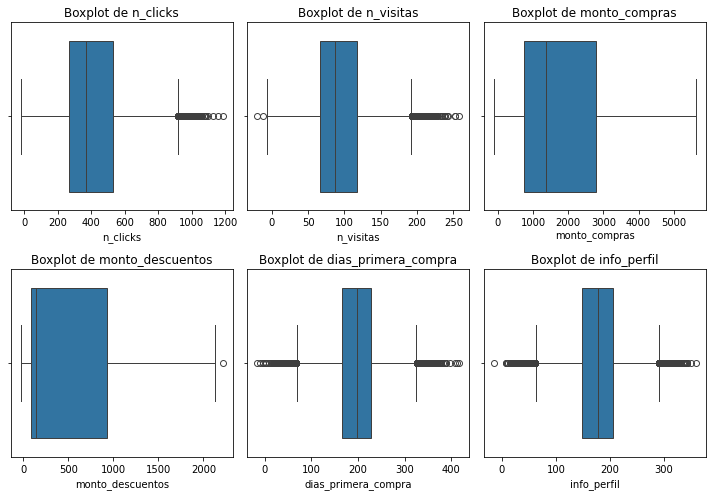

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extraer columnas numéricas
num_cols = df.select_dtypes(include=['number']).columns

# Crear figura vacía
plt.figure(figsize=(10, 7))

# Iterar sobre cada columna numérica y crear boxplot
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x=col)
    plt.title(f'Boxplot de {col}')
plt.tight_layout()

Aunque todas las columnas numéricas contienen valores extremos no podemos determinar si estos realmente son valores atípicos o tienen algún tipo de correspondencia con el comportamiento de los clientes.

Sin embargo, al parecer en las columnas "n_visitas", "dias_primera_compra" e "info_perfil" tenemos valores negativos que definitivamente son atípicos:

In [5]:
df[df[num_cols]<0].count()

ID                     0
n_clicks               2
n_visitas              4
monto_compras          1
monto_descuentos       2
dias_primera_compra    5
info_perfil            1
dtype: int64

En efecto todas las columnas numéricas contienen unos cuantos valores negativos que limpiaremos en un momento.

## 2. Limpieza de datos

In [6]:
# Eliminar filas que contengan datos faltantes
df_clean = df.dropna()
print(f'Tamaño dataset antes de la eliminación de datos faltantes: {df.shape}')
print(f'Tamaño dataset después de la eliminación de datos faltantes: {df_clean.shape}')

Tamaño dataset antes de la eliminación de datos faltantes: (55056, 7)
Tamaño dataset después de la eliminación de datos faltantes: (55021, 7)


In [7]:
# Eliminar la columna ID pues no contiene información relevante
df_clean.drop(columns=['ID'], inplace=True)
df_clean

C:\TEMP/ipykernel_23812/1580864681.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=['ID'], inplace=True)


,n_clicks,n_visitas,monto_compras,monto_descuentos,dias_primera_compra,info_perfil
0,198.0,44.0,3393.0,67.0,241.0,235.0
1,303.0,74.0,3026.3,90.4,193.0,246.0
2,267.0,60.0,3490.2,80.5,111.0,220.0
3,177.0,85.0,3525.1,92.7,142.0,200.0
4,224.0,73.0,2980.9,72.6,227.0,109.0
...,...,...,...,...,...,...
55051,340.0,80.0,601.0,147.2,201.0,149.0
55052,376.0,91.0,1007.5,174.0,226.0,150.0
55053,416.0,52.0,753.1,113.0,188.0,241.0
55054,457.0,60.0,223.2,111.8,199.0,117.0


Y finalmente realizamos la eliminación de los valores extremos negativos usando los métodos "ge()" y "all()":

In [8]:
print(f'Tamaño dataset antes de la eliminación de valores extremos: {df_clean.shape}')
df_clean = df_clean[df_clean[num_cols].ge(0).all(axis=1)]
print(f'Tamaño dataset después de la eliminación de valores extremos: {df_clean.shape}')

Tamaño dataset antes de la eliminación de valores extremos: (55021, 6)
Tamaño dataset después de la eliminación de valores extremos: (55006, 6)


## 3. Análisis exploratorio de datos

Ya tenemos una idea general de la distribución de cada variable (la cual obtuvimos a través de los gráficos de caja) así que en esta sección realizaremos análisis bivariado.

Como nos interesa encontrar segmentos de cliente de acuerdo a su perfil de compradores, las variables más relevantes serán "monto_compras" y "monto_descuentos". Así que la idea es ver cómo las otras covariables se relacionan con estas dos variables de referencia.

Además la idea es detectar otros pares de variables que estén altamente correlacionados para no incluirlos ambas variables al momento de realizar la segmentación de clientes:

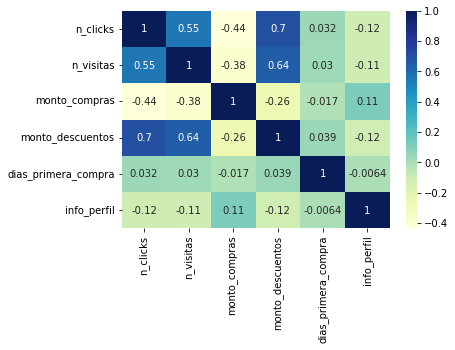

In [9]:
# Graficar matriz de correlación

corr = df_clean.corr()
ax = sns.heatmap(corr, cmap="YlGnBu", annot=True)

No existen niveles de correlación especialmente altos entre los diferentes pares de variables así que preservaremos todas las variables para la construcción del modelo de segmentación.

## 4. Segmentación de clientes usando k-means

Comencemos realizando el escalamiento de los datos (un pre-requisito de k-means):

In [10]:
# Escalamiento
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
Xs=scaler.fit_transform(df_clean)
Xs

array([[0.16      , 0.17054264, 0.6032331 , 0.02999774, 0.57793765,
        0.64957265],
       [0.2493617 , 0.28682171, 0.53794798, 0.04056923, 0.46282974,
        0.68091168],
       [0.2187234 , 0.23255814, 0.62053802, 0.03609668, 0.26618705,
        0.60683761],
       ...,
       [0.34553191, 0.20155039, 0.13324076, 0.05077931, 0.45083933,
        0.66666667],
       [0.38042553, 0.23255814, 0.03890046, 0.05023718, 0.47721823,
        0.31339031],
       [0.29446809, 0.5503876 , 0.14452812, 0.07775017, 0.441247  ,
        0.53276353]], shape=(55006, 6))

Con todas las variables escaladas en el rango de 0 a 1 construyamos un primer modelo de segmentación asumiendo k=4 segmentos de cliente:

In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 4, random_state=23)
kmeans.fit(Xs)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,23
,copy_x,True
,algorithm,'lloyd'


La calidad de cada segmento generado se mide a través de la inercia de las agrupaciones:

In [12]:
kmeans.inertia_

2905.164961025611

Pero no sabemos si este valor es adecuado o no. Así que para determinar el valor óptimo de k debemos usar el método del codo:

Text(0, 0.5, 'Inercia')

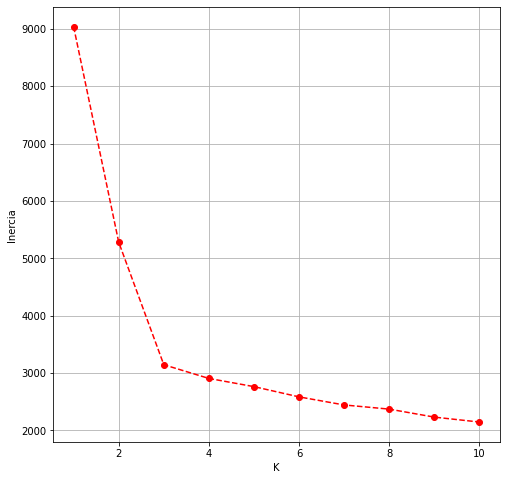

In [13]:
import numpy as np

# Posibles segmentos: k = 1, 2, ... , 10
K = np.arange(1,11)

# Por cada valor de K construir el modelo kmeans y calcular su inercia
inercias = []
for k in K:
  kmeans = KMeans(n_clusters = k, init='k-means++', random_state = 23)
  kmeans.fit(Xs)
  inercias.append(kmeans.inertia_)

# Y generar la gráfica y buscar el "codo"
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(K, inercias, '--ro')
ax.grid(axis='both')
ax.set_xlabel('K')
ax.set_ylabel('Inercia')

Vemos que en K=3 tenemos el codo de la gráfica. Así que usaremos K=3 para definir nuestro modelo final de segmentación:

In [14]:
kmeans = KMeans(n_clusters=3, random_state = 23)
kmeans.fit(Xs)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,23
,copy_x,True
,algorithm,'lloyd'


## 5. Análisis de cada segmento de cliente

Comencemos asignando cada cliente al segmento determinado por el modelo k-means:

In [15]:
kmeans.labels_

array([1, 1, 1, ..., 2, 2, 2], shape=(55006,), dtype=int32)

In [16]:
df_clean['segmento'] = kmeans.labels_
df_clean

C:\TEMP/ipykernel_23812/3160108550.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['segmento'] = kmeans.labels_


,n_clicks,n_visitas,monto_compras,monto_descuentos,dias_primera_compra,info_perfil,segmento
0,198.0,44.0,3393.0,67.0,241.0,235.0,1
1,303.0,74.0,3026.3,90.4,193.0,246.0,1
2,267.0,60.0,3490.2,80.5,111.0,220.0,1
3,177.0,85.0,3525.1,92.7,142.0,200.0,1
4,224.0,73.0,2980.9,72.6,227.0,109.0,1
...,...,...,...,...,...,...,...
55051,340.0,80.0,601.0,147.2,201.0,149.0,2
55052,376.0,91.0,1007.5,174.0,226.0,150.0,2
55053,416.0,52.0,753.1,113.0,188.0,241.0,2
55054,457.0,60.0,223.2,111.8,199.0,117.0,2


Y podemos generar por ejemplo gráficos tipo "box-plot" por cada una de las características y para cada segmento:

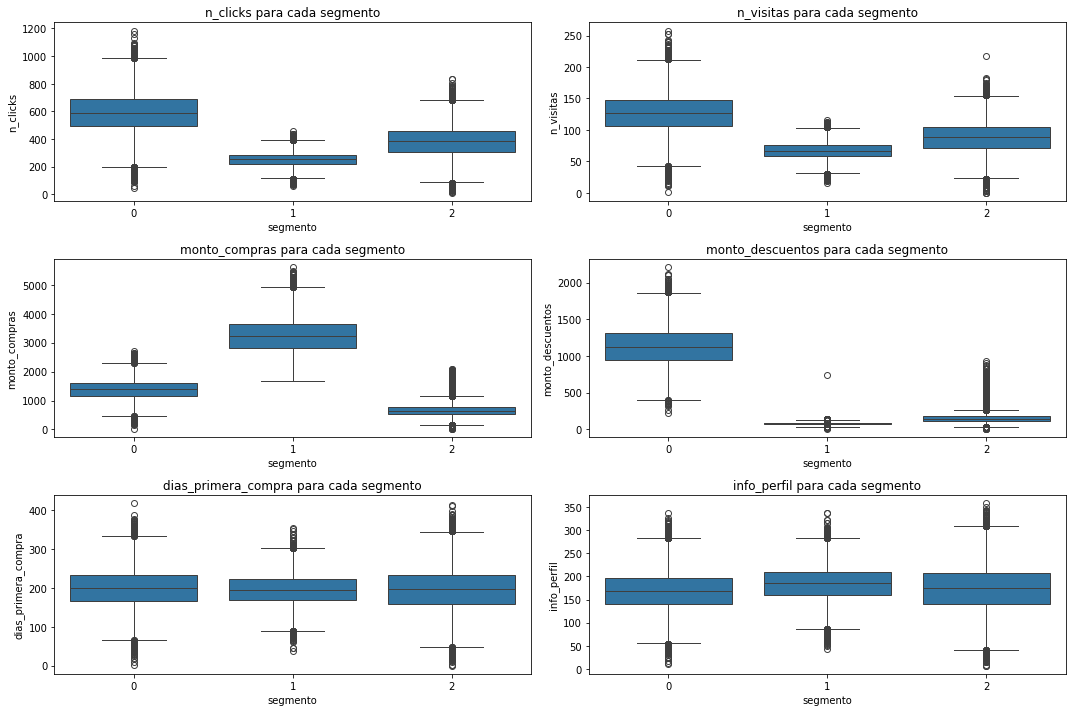

In [17]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(['n_clicks', 'n_visitas', 'monto_compras', 'monto_descuentos', 'dias_primera_compra', 'info_perfil'], 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='segmento', y=col, data=df_clean)
    plt.title(f'{col} para cada segmento')
plt.tight_layout()
plt.show()

Vemos que las variables "dias_primera_compra" e "info_perfil" son muy similares entre los diferentes grupos así que podremos eliminarlas para facilitar el análisis:

In [18]:
segmentos = df_clean.copy()
segmentos.drop(columns=['dias_primera_compra', 'info_perfil'], inplace=True)
segmentos

,n_clicks,n_visitas,monto_compras,monto_descuentos,segmento
0,198.0,44.0,3393.0,67.0,1
1,303.0,74.0,3026.3,90.4,1
2,267.0,60.0,3490.2,80.5,1
3,177.0,85.0,3525.1,92.7,1
4,224.0,73.0,2980.9,72.6,1
...,...,...,...,...,...
55051,340.0,80.0,601.0,147.2,2
55052,376.0,91.0,1007.5,174.0,2
55053,416.0,52.0,753.1,113.0,2
55054,457.0,60.0,223.2,111.8,2


Ahora la idea es intentar visualizar todas las variables de manera simultánea. Una herramienta muy útil son los gráficos de radar.

Comencemos agrupando el DataFrame anterior por segmentos y agregando por el promedio:

In [19]:
radar = segmentos.groupby("segmento").mean()
radar

,n_clicks,n_visitas,monto_compras,monto_descuentos
segmento,,,,
0,590.338081,127.080723,1384.510281,1133.192974
1,253.252164,66.625472,3246.384007,80.177969
2,384.446163,88.775604,673.935837,151.889522


Y ahora generemos el gráfico de radar con ayuda de Plotly:

In [20]:
import plotly.graph_objects as go

# Contenedor de la figura
fig = go.Figure()

# Gráfico de radar para cada segmento
fig.add_trace(go.Scatterpolar(
    r=radar.iloc[0],
    theta=radar.columns,
    fill='toself', # Rellenar el gráfico
    name='Segmento 0'
))

fig.add_trace(go.Scatterpolar(
    r=radar.iloc[1],
    theta=radar.columns,
    fill='toself',
    name='Segmento 1'
))

fig.add_trace(go.Scatterpolar(
    r=radar.iloc[2],
    theta=radar.columns,
    fill='toself',
    name='Segmento 2'
))

fig.show()

ModuleNotFoundError: No module named 'plotly'

Como las escalas de las variables de interés son diferentes, al generar el gráfico de radar resulta difícil apreciar algunos detalles.

Usemos el dataset escalado para construir el gráfico de radar:

In [ ]:
# DataFrame con las variables de interés escaladas
segmentos_s = pd.DataFrame(Xs, columns=df_clean.columns[:-1])
segmentos_s['segmento'] = kmeans.labels_
segmentos_s.drop(columns=['dias_primera_compra', 'info_perfil'], inplace=True)
segmentos_s

,n_clicks,n_visitas,monto_compras,monto_descuentos,segmento
0,0.160000,0.170543,0.603233,0.029998,1
1,0.249362,0.286822,0.537948,0.040569,1
2,0.218723,0.232558,0.620538,0.036097,1
3,0.142128,0.329457,0.626751,0.041608,1
4,0.182128,0.282946,0.529865,0.032528,1
...,...,...,...,...,...
55001,0.280851,0.310078,0.106162,0.066230,2
55002,0.311489,0.352713,0.178533,0.078337,2
55003,0.345532,0.201550,0.133241,0.050779,2
55004,0.380426,0.232558,0.038900,0.050237,2


De nuevo generemos las agrupaciones de cada segmento y calculemos los promedios:

In [ ]:
radar_s = segmentos_s.groupby("segmento").mean()
radar_s

,n_clicks,n_visitas,monto_compras,monto_descuentos
segmento,,,,
0,0.493905,0.492561,0.245653,0.511675
1,0.207023,0.258238,0.577130,0.035951
2,0.318678,0.344091,0.119147,0.068349


Y generemos los nuevos gráficos de radar:

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=radar_s.iloc[0],
    theta=radar_s.columns,
    fill='toself',
    name='Segmento 0'
))

fig.add_trace(go.Scatterpolar(
    r=radar_s.iloc[1],
    theta=radar_s.columns,
    fill='toself',
    name='Segmento 1'
))

fig.add_trace(go.Scatterpolar(
    r=radar_s.iloc[2],
    theta=radar_s.columns,
    fill='toself',
    name='Segmento 2'
))

Y con esto ya podemos caracterizar claramente cada uno de los segmentos. Por último podemos retomar el promedio de cada variable para cada segmento (sin escalamiento) para completar esta caracterización:

In [21]:
radar

,n_clicks,n_visitas,monto_compras,monto_descuentos
segmento,,,,
0,590.338081,127.080723,1384.510281,1133.192974
1,253.252164,66.625472,3246.384007,80.177969
2,384.446163,88.775604,673.935837,151.889522
